#Importing necessary product 

In [1]:
import tensorflow as tf
import numpy as np
import seaborn as sns
import tkinter as tk
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tkinter.filedialog import askopenfilename
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
print("test 1")



test 1


# test 


In [2]:
train_dir = "train"
valid_dir = "valid"
test_dir  = "test"

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

valid_data = train_gen.flow_from_directory(
    valid_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

Found 7946 images belonging to 70 classes.
Found 700 images belonging to 70 classes.


In [3]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [4]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)


C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
102/249 ━━━━━━━━━━━━━━━━━━━━ 1:27 593ms/step - accuracy: 0.2832 - loss: 3.1595

KeyboardInterrupt: 

In [ ]:
model.save("dog_breed_model.h5")


Selected Image: C:/Users/DELL/Downloads/Mountain.jpg


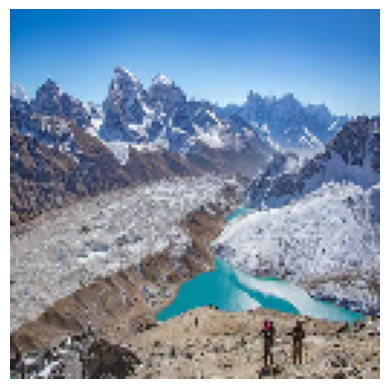

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Breed: Greyhound
Confidence: 32.35%


In [18]:
from tensorflow.keras.models import load_model

model = load_model("dog_breed_model.h5")
# file picker
root = tk.Tk()
root.withdraw()

file_path = askopenfilename()

print("Selected Image:", file_path)

# Load image
img = image.load_img(file_path, target_size=(128,128))

# Display image
plt.imshow(img)
plt.axis("off")
plt.show()

# Convert image to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Get class names
class_names = list(train_data.class_indices.keys())

# Predicted class
predicted_index = np.argmax(prediction)

predicted_breed = class_names[predicted_index]

# Confidence
confidence = np.max(prediction) * 100

print(f"Predicted Breed: {predicted_breed}")
print(f"Confidence: {confidence:.2f}%")

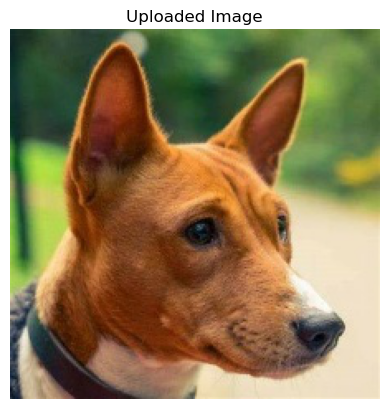

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
basenji


In [26]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import (
    MobileNetV2,
    preprocess_input,
    decode_predictions
)
from tkinter import Tk, filedialog

#  model loading for dog detection 
model = MobileNetV2(weights="imagenet")


# Showing image
def show_image(img_path):
    img = image.load_img(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Uploaded Image")
    plt.show()


# Better dog detection using predefine model
def is_dog(decoded_preds):
    for _, name, _ in decoded_preds:
        name = name.lower()
        if "dog" in name or "retriever" in name or "terrier" in name or \
           "husky" in name or "shepherd" in name or "poodle" in name or \
           "bulldog" in name or "beagle" in name or "spaniel" in name:
            return True
    return False


def predict_image(img_path):
    show_image(img_path)

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = model.predict(img_array)
    decoded = decode_predictions(preds, top=5)[0]

    # checking is_dog or not 
    if is_dog(decoded):
        
        print(decoded[0][1])
    else:
        print("It does not look like a dog, please provide an image of a dog.")


# FILE UPLOAD
Tk().withdraw()
img_path = filedialog.askopenfilename(
    title="Select an image",
    filetypes=[("Image Files", "*.jpg *.jpeg *.png")]
)

if img_path:
    predict_image(img_path)
else:
    print("No image selected")

In [ ]:
# Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Final Training Accuracy:", train_acc)
print("Final Validation Accuracy:", val_acc)

In [ ]:
test_data = train_gen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

In [ ]:
test_loss, test_acc = model.evaluate(test_data)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

In [ ]:
pred = model.predict(test_data)
pred_classes = np.argmax(pred, axis=1)

cm = confusion_matrix(test_data.classes, pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    test_data.classes,
    pred_classes,
    target_names=list(test_data.class_indices.keys())
))